Colab Block to generate Graphs for the paper

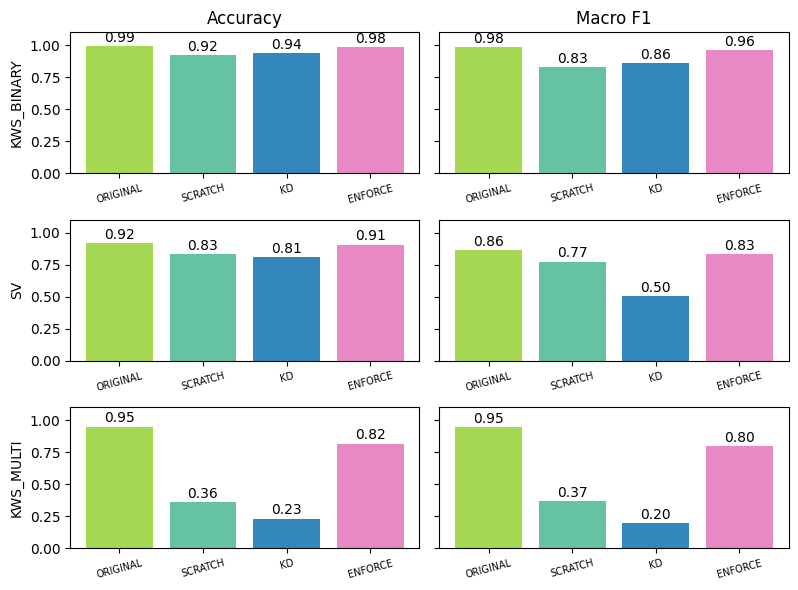

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define tasks and metrics
tasks = ["KWS_BINARY", "SV", "KWS_MULTI"]
metrics = ["Accuracy", "Macro F1"]
methods = ["ORIGINAL", "SCRATCH", "KD", "ENFORCE"]

values = {
    "KWS_BINARY": {
        "Accuracy":   [0.9928, 0.9202, 0.9392, 0.9842],
        "Macro F1":   [0.9827, 0.8256, 0.8587, 0.9637]
    },
    "SV": {
        "Accuracy":   [0.9160, 0.8300, 0.8761, 0.9063],
        "Macro F1":   [0.8624, 0.7746, 0.8042, 0.8345]
    },
    "KWS_MULTI": {
        "Accuracy":   [0.9510, 0.3600, 0.7656, 0.8180],
        "Macro F1":   [0.9488, 0.3660, 0.7348, 0.7990]
    }
}

x = np.arange(len(methods))
fig, axes = plt.subplots(len(tasks), len(metrics), figsize=(8, 6), sharey=True)

for i, task in enumerate(tasks):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        vals = values[task][metric]
        ax.bar(x, vals, color=["#a6d854", "#66c2a5", "#3288bd", "#e78ac3"])

        for k, v in enumerate(vals):
            ax.text(k, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=10)

        if i == 0:
            ax.set_title(metric)
        if j == 0:
            ax.set_ylabel(task)

        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=15, fontsize=7)
        ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

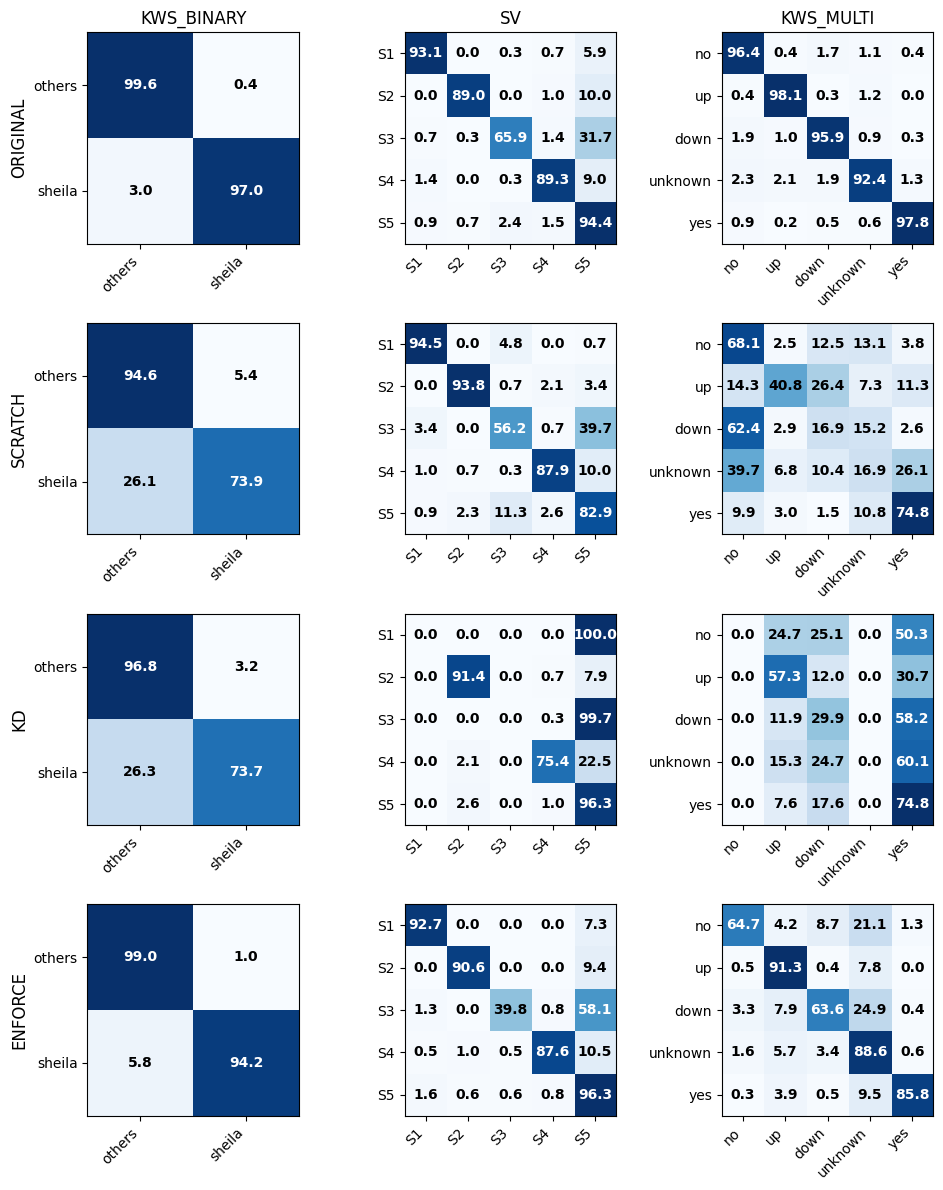

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define tasks (columns) and baselines (rows)
tasks = ["KWS_BINARY", "SV", "KWS_MULTI"]
baselines = ["ORIGINAL", "SCRATCH", "KD", "ENFORCE"]

conf_matrices = {
    "ORIGINAL": {"KWS_BINARY": np.array([[99.6, 0.4], [3.0, 97.0]]),
                 "SV": np.array([[93.1, 0.0, 0.3, 0.7, 5.9],
                                 [0.0, 89.0, 0.0, 1.0, 10.0],
                                 [0.7, 0.3, 65.9, 1.4, 31.7],
                                 [1.4, 0.0, 0.3, 89.3, 9.0],
                                 [0.9, 0.7, 2.4, 1.5, 94.4]]),
                 "KWS_MULTI": np.array([[96.4, 0.4, 1.7, 1.1, 0.4],
                                        [0.4, 98.1, 0.3, 1.2, 0.0],
                                        [1.9, 1.0, 95.9, 0.9, 0.3],
                                        [2.3, 2.1, 1.9, 92.4, 1.3],
                                        [0.9, 0.2, 0.5, 0.6, 97.8]])},
    "SCRATCH": {"KWS_BINARY": np.array([[94.6, 5.4], [26.1, 73.9]]),
                "SV": np.array([[94.5, 0.0, 4.8, 0.0, 0.7],
                                [0.0, 93.8, 0.7, 2.1, 3.4],
                                [3.4, 0.0, 56.2, 0.7, 39.7],
                                [1.0, 0.7, 0.3, 87.9, 10.0],
                                [0.9, 2.3, 11.3, 2.6, 82.9]]),
                "KWS_MULTI": np.array([[68.1, 2.5, 12.5, 13.1, 3.8],
                                       [14.3, 40.8, 26.4, 7.3, 11.3],
                                       [62.4, 2.9, 16.9, 15.2, 2.6],
                                       [39.7, 6.8, 10.4, 16.9, 26.1],
                                       [9.9, 3.0, 1.5, 10.8, 74.8]])},
    "KD": {"KWS_BINARY": np.array([[96.8, 3.2], [26.3, 73.7]]),
           "SV": np.array([[92.0, 1.2, 0.3, 0.3, 6.2],
                           [0.0, 90.2, 1.9, 2.1, 5.8],
                           [1.4, 0.0, 37.9, 0.3, 61.8],
                           [0.0, 2.1, 1.9, 85.3, 10.7],
                           [0.6, 5.3, 2.3, 1.3, 91.6]]),
           "KWS_MULTI": np.array([[72.6, 1.0, 6.0, 19.8, 0.5],
                                  [1.3, 84.1, 1.1, 13.3, 0.1],
                                  [1.0, 2.2, 59.1, 27.4, 0.4],
                                  [5.3, 2.4, 5.1, 84.7, 1.4],
                                  [2.4, 1.0, 0.4, 16.5, 79.8]])},
    "ENFORCE": {"KWS_BINARY": np.array([[99.0, 1.0], [5.8, 94.2]]),
                "SV": np.array([[92.7, 0.0, 0.0, 0.0, 7.3],
                                [0.0, 90.6, 0.0, 0.0, 9.4],
                                [1.3, 0.0, 39.8, 0.8, 58.1],
                                [0.5, 1.0, 0.5, 87.6, 10.5],
                                [1.6, 0.6, 0.6, 0.8, 96.3]]),
                "KWS_MULTI": np.array([[64.7, 4.2, 8.7, 21.1, 1.3],
                                       [0.5, 91.3, 0.4, 7.8, 0.0],
                                       [3.3, 7.9, 63.6, 24.9, 0.4],
                                       [1.6, 5.7, 3.4, 88.6, 0.6],
                                       [0.3, 3.9, 0.5, 9.5, 85.8]])}
}

classes_dict = {
    "KWS_BINARY": ["others", "sheila"],
    "SV": ["S1", "S2", "S3", "S4", "unknown"],
    "KWS_MULTI": ["no", "up", "down", "unknown", "yes"]
}

fig, axes = plt.subplots(len(baselines), len(tasks), figsize=(10, 12))

for i, baseline in enumerate(baselines):
    for j, task in enumerate(tasks):
        ax = axes[i, j]
        cm = conf_matrices[baseline][task]
        im = ax.imshow(cm, cmap="Blues")

        # Add text annotations
        for r in range(cm.shape[0]):
            for c in range(cm.shape[1]):
                color = "white" if cm[r, c] >= 50 else "black"
                ax.text(c, r, f"{cm[r, c]:.1f}", ha="center", va="center", color=color, fontsize=10, weight="bold")

        # Titles and axis labels
        if i == 0:
            ax.set_title(task, fontsize=12)
        if j == 0:
            ax.set_ylabel(baseline, fontsize=12)

        # Set class labels
        classes = classes_dict[task]
        ax.set_xticks(range(len(classes)))
        ax.set_yticks(range(len(classes)))
        ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=10)
        ax.set_yticklabels(classes, fontsize=10)

# Adjust layout
plt.subplots_adjust(wspace=-0.02, hspace=0.2)
plt.tight_layout()
plt.show()


/var/folders/p_/nhzw9byx1q730tv9rcf5_6gm0000gn/T/ipykernel_28228/2321327737.py:18: RuntimeWarning: invalid value encountered in log
  return a * np.log(x + b) + c


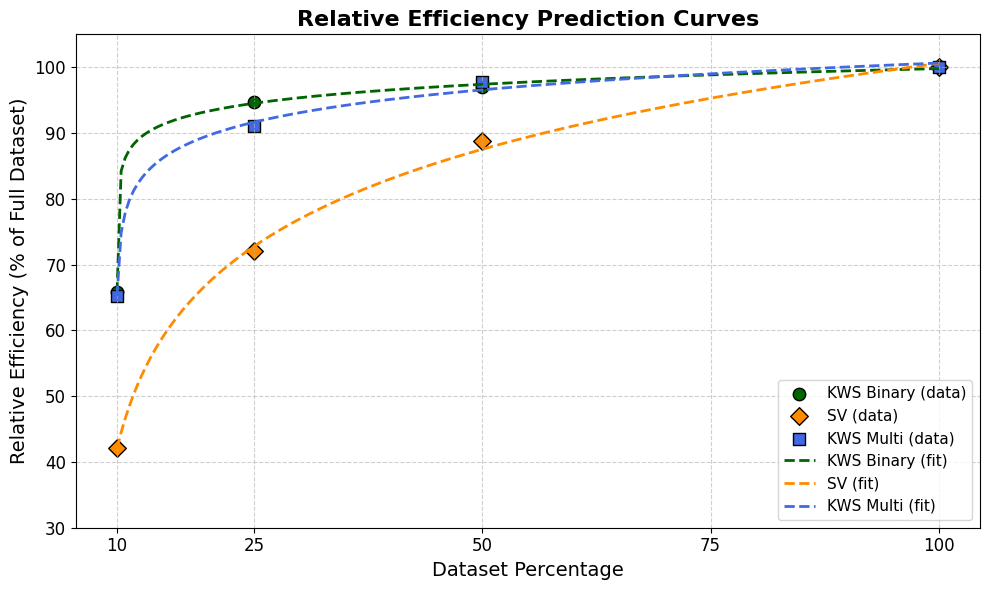

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
percentages = np.array([10, 25, 50, 100])

test_f1_macro_kws_binary = {10: 0.6337, 25: 0.9125, 50: 0.9351, 100: 0.9637}
test_f1_macro_sv = {10: 0.3787, 25: 0.6491, 50: 0.7985, 100: 0.9000}
test_f1_macro_kws_multi = {10: 0.5152, 25: 0.7198, 50: 0.7721, 100: 0.7900}

y_kws_binary = np.array([test_f1_macro_kws_binary[p] for p in percentages])
y_sv = np.array([test_f1_macro_sv[p] for p in percentages])
y_kws_multi = np.array([test_f1_macro_kws_multi[p] for p in percentages])

# Logarithmic fit
def log_fit(x, a, b, c):
    return a * np.log(x + b) + c

popt_bin, _ = curve_fit(log_fit, percentages, y_kws_binary, maxfev=10000)
popt_sv, _ = curve_fit(log_fit, percentages, y_sv, maxfev=10000)
popt_multi, _ = curve_fit(log_fit, percentages, y_kws_multi, maxfev=10000)

x_smooth = np.linspace(10, 100, 200)
y_bin_fit_rel = log_fit(x_smooth, *popt_bin) / y_kws_binary[-1] * 100
y_sv_fit_rel = log_fit(x_smooth, *popt_sv) / y_sv[-1] * 100
y_multi_fit_rel = log_fit(x_smooth, *popt_multi) / y_kws_multi[-1] * 100

# Apply plotting style
plt.style.use("seaborn-v0_8-muted")

plt.figure(figsize=(10, 6))

# Scatter plots (data points)
plt.scatter(percentages, y_kws_binary / y_kws_binary[-1] * 100,
            color="darkgreen", marker="o", s=80, edgecolor="black", label="KWS Binary (data)")
plt.scatter(percentages, y_sv / y_sv[-1] * 100,
            color="darkorange", marker="D", s=80, edgecolor="black", label="SV (data)")
plt.scatter(percentages, y_kws_multi / y_kws_multi[-1] * 100,
            color="royalblue", marker="s", s=80, edgecolor="black", label="KWS Multi (data)")

# Fitted curves
plt.plot(x_smooth, y_bin_fit_rel, color="darkgreen", linestyle="--", linewidth=2, label="KWS Binary (fit)")
plt.plot(x_smooth, y_sv_fit_rel, color="darkorange", linestyle="--", linewidth=2, label="SV (fit)")
plt.plot(x_smooth, y_multi_fit_rel, color="royalblue", linestyle="--", linewidth=2, label="KWS Multi (fit)")

# Labels & title
plt.xlabel("Dataset Percentage", fontsize=14)
plt.ylabel("Relative Efficiency (% of Full Dataset)", fontsize=14)
plt.title("Relative Efficiency Prediction Curves", fontsize=16, weight="bold")

# Formatting
plt.ylim(30, 105)
plt.xticks([10, 25, 50, 75, 100], fontsize=12)
plt.yticks(np.arange(30, 110, 10), fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11, frameon=True, loc="lower right")
plt.tight_layout()
plt.show()
